## Import

In [131]:
import random
import numpy as np 
import pandas as pd 
import ast
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import time
from scipy.stats import zscore

import re
import string
from functools import lru_cache
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from joblib import Parallel, delayed
from sklearn.preprocessing import MinMaxScaler

## Problemas surgidos
Durante el desarrollo del programa de recomendación colaborativo (filtrado por contenido) han surgido una serie de problemas que se van a listar a continuación:

    - Gran cantidad de datos de los archivos CSV.
    - Dispersión de los datos.
    - Implementación del sistema de recomendación híbrido.

## Métodos necesarios

In [132]:

# Reemplaza los valores atípicos que pueden generar confusión
def arreglar_dispersion(df, columnas, z_score_umbral):
    for col in columnas:
        # Z-score mide cuántas desviaciones estándar se encuentra un valor respecto a la media.
        z_scores = np.abs(zscore(df[col], nan_policy='omit'))  # Calcula Z-score (da un valor indicando cuánta desviación tiene de la media)
        df.loc[z_scores > z_score_umbral, col] = np.nan  # Sustituye atípicos con NaN (en el caso de que la desviación sea mayor que el umbral)


In [133]:
# Se podría eliminar este método
def comprobar_dispersion(df, cols):
    z_scores = df[cols].apply(zscore)

# Contar cuántos valores atípicos hay en cada columna (valores con |Z-score| > 3)
    outlier_counts = (abs(z_scores) > 3).sum()

# Mostrar columnas con valores atípicos
    print(outlier_counts[outlier_counts > 0].sort_values(ascending=False))

In [134]:
def limpiador_nombres(df_a_limpiar):
    # Limpiar nombres de columnas: convertir a minúsculas y reemplazar espacios por '_'
    
    df_a_limpiar.columns = df_a_limpiar.columns.str.lower().str.replace(' ', '_')

    return df_a_limpiar

## Código

### Constantes

In [135]:
# Columnas seleccionas del dataset con la información de los juegos
INFO_JUEGO_COLS = ['id',
                   'primary',
                   'yearpublished',
                   'playingtime',
                   'boardgamecategory', 
                   'maxplayers',
                   'average']

# Columans seleccionadas de las reviews
RATING_COLS = ['user',
               'rating',
               'ID', 
               'comment']

PROBABILIDAD_FALLO = 0.2
TOP_JUEGOS = 1000
PORCENTAJE = 0.1
VOTOS_MINIMOS = 10
DELIMITADOR_Z_SCORE = 3
EJEMPLO_USUARIO = None
VALORACION_USUARIO_UMBRAL = 5


FILTRO_CATEGORIA = {
    "boardgamecategory": None
}
FILTRO_NUMERICO = {
    "playingtime": None,
    "average": {"measure": "above", "threshold": 7}
}


In [136]:
# Semilla aleatoria utilizando el tiempo del sistema
random.seed(int(time.time()))
# Permite transformar los usuarios a números enteros
label_encoder = LabelEncoder()

# Para mostrar datos de forma gráfica
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)

In [137]:
# Lectura CSV
info_juegos = pd.read_csv("../data/games_detailed_info.csv",
        usecols=INFO_JUEGO_COLS, 
        dtype={'id': 'uint32', 
                'primary': 'string', 
                'yearpublished': 'uint16', 
                'maxplayers': 'uint16',
                'playingtime': 'uint32',
                'average': 'float16'
                })


# Solucionar dispersión, sustituye por nan
arreglar_dispersion(info_juegos, ['playingtime', 'maxplayers'], DELIMITADOR_Z_SCORE)

# Eliminar nulos, duplicados.
info_juegos = info_juegos.dropna()
info_juegos = info_juegos.drop_duplicates()

#  Eliminar espacios en blanco, mayúsculas y reduce a dos decimales la valoración media
info_juegos['primary'] = info_juegos['primary'].str.lower()
info_juegos['primary'] = info_juegos['primary'].str.replace(' ', '_')
info_juegos['average'] = info_juegos['average'].apply(lambda x: np.around(x, decimals=2))

In [138]:
# info_juegos.info()
# info_juegos.isnull().values.any()
# info_juegos.isnull().sum().sum()
# info_juegos.head(10)
info_juegos.head()

,id,primary,yearpublished,maxplayers,playingtime,boardgamecategory,average
0,30549,pandemic,2008,4.0,45.0,['Medical'],7.59
1,822,carcassonne,2000,5.0,45.0,"['City Building', 'Medieval', 'Territory Build...",7.42
2,13,catan,1995,4.0,120.0,"['Economic', 'Negotiation']",7.14
3,68448,7_wonders,2010,7.0,30.0,"['Ancient', 'Card Game', 'City Building', 'Civ...",7.73
4,36218,dominion,2008,4.0,30.0,"['Card Game', 'Medieval']",7.61


In [139]:
info_juegos.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 21097 entries, 0 to 21630
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 21097 non-null  uint32 
 1   primary            21097 non-null  string 
 2   yearpublished      21097 non-null  uint16 
 3   maxplayers         21097 non-null  float64
 4   playingtime        21097 non-null  float64
 5   boardgamecategory  21097 non-null  object 
 6   average            21097 non-null  float64
dtypes: float64(3), object(1), string(1), uint16(1), uint32(1)
memory usage: 4.2 MB


In [140]:
reviews = pd.read_csv("../data/bgg-26m-reviews.csv", 
                      usecols=RATING_COLS, 
                      skiprows=lambda x: x > 0 and random.random() >= PROBABILIDAD_FALLO,
                      dtype={'user': 'string', 
                             'rating': 'float16', 
                             'ID': 'uint32',
                             'comment': 'string[pyarrow]' #  Al usar string[pyarrow] se reduce la memoria significativamente
                             }) 

reviews = reviews.dropna()
reviews = reviews.drop_duplicates(subset=["user", "ID"], keep="first")

reviews['rating'] = reviews['rating'].astype(np.int8)

In [141]:
reviews.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 842395 entries, 1 to 5243574
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   user     842395 non-null  string
 1   rating   842395 non-null  int8  
 2   comment  842395 non-null  string
 3   ID       842395 non-null  uint32
dtypes: int8(1), string(2), uint32(1)
memory usage: 243.4 MB


In [142]:
reviews.memory_usage(deep=True)

Index        6739160
user        55559549
rating        842395
comment    188696839
ID           3369580
dtype: int64

In [143]:
reviews.head()

,user,rating,comment,ID
1,cypar7,10,"I know it says how many plays, but many, many ...",13
3,hreimer,10,i will never tire of this game.. Awesome,13
6,hurkle,10,Fantastic game. Got me hooked on games all ove...,13
9,PatB,10,Settlers is a gem. If you havn't played it I s...,13
10,Capn_Future,10,"Played this game more than any other, a new cl...",13


In [144]:
# Filtra por los registros que coinciden con el id de info_juegos
reviews = reviews[reviews['ID'].isin(info_juegos['id'])]
reviews.head(4)

,user,rating,comment,ID
1,cypar7,10,"I know it says how many plays, but many, many ...",13
3,hreimer,10,i will never tire of this game.. Awesome,13
6,hurkle,10,Fantastic game. Got me hooked on games all ove...,13
9,PatB,10,Settlers is a gem. If you havn't played it I s...,13


In [145]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
Index: 787809 entries, 1 to 5243549
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   user     787809 non-null  string
 1   rating   787809 non-null  int8  
 2   comment  787809 non-null  string
 3   ID       787809 non-null  uint32
dtypes: int8(1), string(2), uint32(1)
memory usage: 181.6 MB


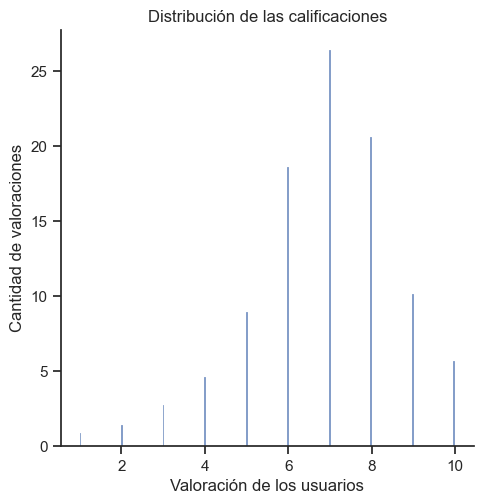

In [146]:
ax = sns.displot(data=reviews, x='rating', stat='percent', fill="blue")
ax.set(xlabel="Valoración de los usuarios",
       ylabel='Cantidad de valoraciones',
       title='Distribución de las calificaciones')

In [147]:
# Genera una tabla agrupando por id de juego y mostrando el número de usuarios que han valorado el juego y la media total de la valoración.
rated_games = reviews.groupby("ID").agg({"rating": "mean", "user": "count"}).reset_index()
rated_games.sort_values("rating", ascending=False)

,ID,rating,user
4592,9673,10.0,1
11604,140995,10.0,1
19639,308566,10.0,1
10555,116970,10.0,1
18144,266381,10.0,2
...,...,...,...
19838,316555,1.0,4
8587,42259,1.0,2
11549,139975,1.0,1
4453,9118,1.0,1


### Sistema de recomendación colaborativo.
Sistema de recomendación colaborativo basado en juegos similiares que el usuario valoró positivamente.

In [148]:
# Ordenado por juego con mayor cantidad de usuarios que han valorado dicho juego
#rated_games = rated_games.sort_values(by='user', ascending=False).head(TOP_JUEGOS)
rated_games.head()

,ID,rating,user
0,1,7.557927,328
1,2,7.150000,40
2,3,7.551079,695
3,4,6.478261,23
4,5,7.394146,1025


Filtrado de aquellos juegos que tengan una cantidad mínima de votos para evitar juegos con pocas valoraciones. De esta forma, se evita hacer recomendaciones de juegos que pueden tener una alta puntuación, pero pocos usuarios han llegado a jugarlo.

In [149]:
# Media de votos 
MEDIA_VOTOS_POR_JUEGO = int(rated_games['user'].mean())

# Cantidad de votos que superan la media.
juegos_superan_media = (rated_games['user'] >= MEDIA_VOTOS_POR_JUEGO).sum()

# Cantidad de votos que deben superar el mínimo de juegos.
MIN_JUEGOS = int(len(info_juegos) * PORCENTAJE)

# Número de juegos que se van a seleccionar.
SELECCION = int(juegos_superan_media * 0.3)

print(MIN_JUEGOS)
print(juegos_superan_media)

# Se filtra según los votos y la cantidad de votos que supera el mínimo de votos.
if MEDIA_VOTOS_POR_JUEGO > 0 and juegos_superan_media > MIN_JUEGOS:
    rated_games = rated_games[rated_games["user"] >= MEDIA_VOTOS_POR_JUEGO].head(SELECCION) # Se toma solo un porcentaje de todas las reviews.
    

sample_reviews = reviews[reviews['ID'].isin(rated_games['ID'])]
sample_reviews.count()


2109
3646


user       206210
rating     206210
comment    206210
ID         206210
dtype: int64

In [150]:
sample_reviews.head()

,user,rating,comment,ID
1,cypar7,10,"I know it says how many plays, but many, many ...",13
3,hreimer,10,i will never tire of this game.. Awesome,13
6,hurkle,10,Fantastic game. Got me hooked on games all ove...,13
9,PatB,10,Settlers is a gem. If you havn't played it I s...,13
10,Capn_Future,10,"Played this game more than any other, a new cl...",13


In [151]:
sample_reviews.memory_usage(deep=True)

Index       1649680
user       13568758
rating       206210
comment    39082859
ID           824840
dtype: int64

#### Matriz de interacción
Creación de la matriz de interacción donde el índice es el nombre del usuario, las columnas son los juegos y los valores son las valoraciones de dichos juegos por un usuario concreto

In [152]:
# Creación de la matriz de interacción. x = ID, y = user, valor = rating
games_matrix = sample_reviews.pivot_table(index='user', columns='ID', values='rating')

# Se rellenan los nulos con ceros para cálculos posteriores.
# games_matrix.fillna(0) 
games_matrix.head()


ID,1,2,3,5,7,9,10,11,12,13,...,20134,20437,20542,20545,20551,20806,20847,20865,20963,21050
user,,,,,,,,,,,,,,,,,,,,,
-Johnny-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-LucaS-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-PEDROPABLO-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-xXx-,NaN,NaN,10.0,NaN,NaN,NaN,NaN,NaN,7.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
.JcK.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Usuario aleatorio
Coge un usuario de forma aleatoria

In [153]:
if EJEMPLO_USUARIO is None:
    user_id = games_matrix.sample(n=1, axis=0).index[0]
else:
    user_id = EJEMPLO_USUARIO
    
print(user_id)

DarthEd


In [154]:
# Busca las valoraciones de un usuario específico guardándolos como una serie
user_ratings = games_matrix.loc[user_id]
user_ratings = user_ratings.dropna()
user_ratings.head()

ID
12       4.0
760      8.0
2842     7.0
9216     7.0
10547    7.0
Name: DarthEd, dtype: float64

In [155]:
len(user_ratings)

8

In [156]:
# Se filtra por las valoraciones que sean mayores que el umbral
juegos_valorados = user_ratings[user_ratings >= VALORACION_USUARIO_UMBRAL] # Debe ser mayor o igual que 5 para no utilizar valoraciones negativas
df_juegos_valorados = juegos_valorados.reset_index()
df_juegos_valorados.columns = ['ID', 'rating']
df_juegos_valorados.head()

,ID,rating
0,760,8.0
1,2842,7.0
2,9216,7.0
3,10547,7.0
4,12493,8.0


In [157]:
# Serie inicializada que contendrá las ponderaciones
similitud_ponderada = pd.Series(np.zeros(games_matrix.shape[1]), index=games_matrix.columns)
similitud_ponderada.head()

ID
1    0.0
2    0.0
3    0.0
5    0.0
7    0.0
dtype: float64

In [158]:
# juegos_valorados es una serie con el id de los juegos y sus valoraciones del usuario objetivo
for game_id in juegos_valorados.keys():
    # Obtiene la correlación del juego valorado del usuario objetivo con el resto de juegos de games_matrix y devolviendo una serie
    # La correlación va desde -1 a 1
    corr_series = games_matrix.corrwith(games_matrix[game_id])
    corr_series = corr_series + 1
    # Reemplazamos NaN por 0 en la correlación
    corr_series = corr_series.fillna(0)
    # Se suma esa correlación a cada juego de similitud_ponderada
    similitud_ponderada = similitud_ponderada.add(corr_series, fill_value=0)
    

similitud_ponderada = similitud_ponderada.astype(np.float16)


C:\Users\isaac\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\function_base.py:2846: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
C:\Users\isaac\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\function_base.py:2705: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
C:\Users\isaac\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\function_base.py:2705: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
C:\Users\isaac\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c 

In [159]:
len(juegos_valorados) # Total de juegos valorados por el usuario objetivo

7

In [160]:
similitud_ponderada.sort_values(ascending=False).head()

ID
58       11.445312
348      11.429688
1502     11.375000
97       11.257812
10653    11.062500
dtype: float16

In [161]:
# Convertir en promedio ponderado para que no importe si el usuario objetivo ha valorado muchos o pocos juegos. Evita la dispersión
peso_total = len(juegos_valorados) * 2
if peso_total != 0:
    similitud_ponderada = similitud_ponderada / peso_total
    
print(similitud_ponderada.sort_values(ascending=False).head())
len(similitud_ponderada)

ID
58       0.817383
348      0.816406
1502     0.812500
97       0.804199
10653    0.790039
dtype: float16


1093

In [162]:
# Conversión en dataframe
df_similitud_ponderada = similitud_ponderada.reset_index()
df_similitud_ponderada.columns = ['ID', 'ponderacion']

## A partir de aquí análisis de sentimientos con el dataframe sample_reviews

In [163]:
sia = SentimentIntensityAnalyzer()
sample_reviews['sentiment'] = sample_reviews['comment'].apply(
    lambda comment: (sia.polarity_scores(comment)['compound'] + 1) if isinstance(comment, str) else 0)

print(sample_reviews.head())

           user  rating                                            comment  \
1        cypar7      10  I know it says how many plays, but many, many ...   
3       hreimer      10           i will never tire of this game.. Awesome   
6        hurkle      10  Fantastic game. Got me hooked on games all ove...   
9          PatB      10  Settlers is a gem. If you havn't played it I s...   
10  Capn_Future      10  Played this game more than any other, a new cl...   

    ID  sentiment  
1   13     1.9001  
3   13     1.6249  
6   13     1.5574  
9   13     0.7416  
10  13     1.3400  


C:\Users\isaac\AppData\Local\Temp\ipykernel_24400\1039532491.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_reviews['sentiment'] = sample_reviews['comment'].apply(


In [164]:
# Se hace la media de los sentimientos
df_avg_sentiment = sample_reviews.groupby('ID')['sentiment'].mean().reset_index().rename(columns={'sentiment': 'avg_sentiment'})
df_avg_sentiment['avg_sentiment'] = df_avg_sentiment['avg_sentiment'] * 0.5 # Asegura un rango entre 0 y 1 para posteriores cálculos
df_avg_sentiment.sort_values(by='avg_sentiment', ascending=False).head()

,ID,avg_sentiment
588,3154,0.821075
733,5718,0.813312
275,782,0.812369
533,2541,0.811110
456,1814,0.810998


In [165]:
# Elimina de la lista aquellos juegos que el usuario ya ha valorado
user_ratings = user_ratings.index.tolist()
df_similitud_ponderada = df_similitud_ponderada[~df_similitud_ponderada['ID'].isin(user_ratings)]
df_avg_sentiment = df_avg_sentiment[~df_avg_sentiment['ID'].isin(user_ratings)]
print(len(df_similitud_ponderada))
print(len(df_avg_sentiment))

1085
1085


In [166]:
# Filtramos para obtener la ponderación ordenada de forma ascendente
df_similitud_ponderada = df_similitud_ponderada.sort_values(ascending=False, by='ponderacion')
df_similitud_ponderada.head()

,ID,ponderacion
34,58,0.817383
166,348,0.816406
411,1502,0.812500
56,97,0.804199
884,10653,0.790039


In [167]:
# Merge con la información de cada juego, su ponderación y su media de sentimientos.
df_analizado = df_similitud_ponderada.merge(info_juegos, left_on='ID', right_on='id', how='left')
df_analizado = df_analizado.drop(['id'], axis=1)
df_analizado = df_analizado.merge(df_avg_sentiment, left_on='ID', right_on='ID', how='left')
df_analizado.head()

,ID,ponderacion,primary,yearpublished,maxplayers,playingtime,boardgamecategory,average,avg_sentiment
0,58,0.817383,kings_&_things,1986,4.0,120.0,"['Bluffing', 'Exploration', 'Fantasy', 'Humor'...",6.51,0.712013
1,348,0.816406,merchants_of_the_middle_ages,1999,4.0,120.0,"['Economic', 'Medieval', 'Negotiation', 'Trans...",6.73,0.719243
2,1502,0.812500,hotel_tycoon,1974,4.0,60.0,['Economic'],5.49,0.642634
3,97,0.804199,conquest_of_the_empire,1984,6.0,240.0,"['Ancient', 'Economic', 'Wargame']",6.28,0.661307
4,10653,0.790039,pirates_of_the_spanish_main,2004,10.0,30.0,"['Collectible Components', 'Exploration', 'Fig...",6.08,0.714087


In [168]:
# La información completa de aquellos juegos valorados por el usuario objetivo
juegos_valorados_info = info_juegos[info_juegos['id'].isin(df_juegos_valorados['ID'])]


# Filtrado de categorías jugadas por el usuario objetivo
game_category = juegos_valorados_info['boardgamecategory'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

FILTRO_CATEGORIA = {categoria for lista in game_category for categoria in lista}
juegos_valorados_info.count()

id                   7
primary              7
yearpublished        7
maxplayers           7
playingtime          7
boardgamecategory    7
average              7
dtype: int64

In [169]:
print(FILTRO_CATEGORIA)

{'Trains', 'Deduction', 'Ancient', 'Renaissance', 'Party Game', 'Card Game', 'Trivia', 'Economic', 'Nautical', 'Miniatures', 'Adventure', 'Bluffing', 'Novel-based', 'Fighting', 'Wargame', 'Farming', 'Negotiation', 'Space Exploration', 'Political', 'Civilization', 'Exploration', 'Horror', 'Science Fiction'}


In [170]:
# Construir la máscara inicial con False para todas las filas de df_analizado
mask = pd.Series(False, index=df_analizado.index)

# Para cada categoría de las valoradas por el usuario, actualiza la máscara
for categoria in FILTRO_CATEGORIA:
    mask |= df_analizado['boardgamecategory'].fillna("").str.contains(categoria, case=False, regex=True)

df_analizado = df_analizado[mask]

df_analizado.head()

,ID,ponderacion,primary,yearpublished,maxplayers,playingtime,boardgamecategory,average,avg_sentiment
0,58,0.817383,kings_&_things,1986,4.0,120.0,"['Bluffing', 'Exploration', 'Fantasy', 'Humor'...",6.51,0.712013
1,348,0.816406,merchants_of_the_middle_ages,1999,4.0,120.0,"['Economic', 'Medieval', 'Negotiation', 'Trans...",6.73,0.719243
2,1502,0.812500,hotel_tycoon,1974,4.0,60.0,['Economic'],5.49,0.642634
3,97,0.804199,conquest_of_the_empire,1984,6.0,240.0,"['Ancient', 'Economic', 'Wargame']",6.28,0.661307
4,10653,0.790039,pirates_of_the_spanish_main,2004,10.0,30.0,"['Collectible Components', 'Exploration', 'Fig...",6.08,0.714087


### Unión de similitud ponderada y promedio de sentimientos
A continuación se le atribuirá un 80% a la similitud ponderada y un 20% al promedio de sentimientos para realizar la recomendación de juegos.

In [171]:
df_analizado['recomendacion_calculada'] = (df_analizado['ponderacion']) * 0.8 + (df_analizado['avg_sentiment'] * 0.2)
df_analizado = df_analizado.nlargest(5, 'recomendacion_calculada')
print(f"Recomendaciones para el usuario {user_id}")
print(df_analizado[['ID', 'primary', 'recomendacion_calculada']])

Recomendaciones para el usuario DarthEd
     ID                       primary  recomendacion_calculada
1   348  merchants_of_the_middle_ages                 0.796681
0    58                kings_&_things                 0.796211
5  3139                      goldland                 0.786612
2  1502                  hotel_tycoon                 0.778429
3    97        conquest_of_the_empire                 0.775328


## Bibliografía